# Información del proyecto

## Propuesta inicial

En un contexto donde plataformas como Spotify o YouTube concentran gran parte del consumo musical, los artistas independientes enfrentan desafíos relacionados con la transparencia en los ingresos, la detección de usos no autorizados de su obra y la optimización de sus estrategias de lanzamiento. Este proyecto propone abordar estas problemáticas mediante el desarrollo de tres módulos principales basados en datos existentes. Los módulos son:

1. Análisis de mercado musical, orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).

2. Detección de fraude en streams, mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.

3. Detector de copyright basado en inteligencia artificial, capaz de identificar la presencia de contenido musical en diferentes plataformas digitales mediante técnicas de procesamiento de audio, como espectrogramas y huellas digitales (audio fingerprinting), inspirado en tecnologías utilizadas por empresas como Shazam.

## Información de los módulos:



**1. Analisis del mercado musical apra el artista:**

* Datos posibles: Streams por país, Género musical, Playlist placement, TikTok trends, Crecimiento de artistas similares...

* Análisis (EDA): crecimiento por género, países con más crecimiento, correlación entre playlist y streams, horas/días con más reproducciones

* ML posible: Predicción de streams de una canción, Predicción de viralidad, 
* Modelos: Random Forest, XGBoost, LSTM para series temporales

* Output en tu plataforma

“Tu canción tiene 65% probabilidad de viralizarse en México”, “Este beat funciona mejor en playlist de chill trap”

* EXTRA DATOS: EDAD DE LA AUDIENCIA PARA AVERIGUAR TARGET SEGÚN PLATAFORMA. (MÉTRICAS AUDIENCIA TIK TOK)

**2. Fraude en streams:**

* Variables generales para objetivo 2:

| Variable                 | Tipo de dato | Para qué sirve                    | Ejemplo          |
| ------------------------ | ------------ | --------------------------------- | ---------------- |
| user_id                  | categorical  | identificar usuarios únicos       | U10233           |
| track_id                 | categorical  | identificar canción               | TRK8891          |
| session_id               | categorical  | identificar sesión                | S78123           |
| timestamp                | datetime     | detectar patrones temporales      | 2025-03-20 03:10 |
| listen_duration          | float        | detectar streams muy cortos       | 8.2 sec          |
| track_length             | float        | comparar duración real            | 180 sec          |
| completion_rate          | float        | ratio escucha completa            | 0.05             |
| device_type              | categorical  | bots usan dispositivos repetidos  | mobile / desktop |
| country                  | categorical  | detectar granjas de streams       | IN, RU           |
| playlist_source          | categorical  | detectar playlists sospechosas    | algorithmic      |
| repeat_count             | integer      | repeticiones consecutivas         | 25               |
| unique_tracks_in_session | integer      | bots suelen repetir pocas         | 1                |
| skip_rate                | float        | detectar skip masivo              | 0.90             |
| time_between_streams     | float        | bots tienen intervalos constantes | 5 sec            |


* Variables para futures engineering:

| Feature          | Fórmula                 |
| ---------------- | ----------------------- |
| repeat_ratio     | repeats / total streams |
| avg_listen_time  | mean(listen_duration)   |
| stream_frequency | streams / hour          |
| session_entropy  | diversidad de canciones |
| country_entropy  | diversidad geográfica   |


**3. Detector de copyright usando IA (Music Information Retrieval (MIR)):** --> Deep learning; necesario mucha info(canciones), mucho alamenamiento y procesamiento. Necesario mucha inversion. --> Podria hacerse muestra pequeña

--> Convertir cancoin a espectograma y usar redes neuronales para comparar canciones.

* Sistemas comerciales como Shazam usan huellas acústicas para identificar canciones.


* Modelo ML: con CNN usar como si fuera una imagen. 
* Al tratar info como imagen del sonido los ejes son: X = tiempo, Y = frecuencia y Color = energía.
* Variables generales para el punto 3: 

| Variable         | Tipo         | Para qué sirve                  | Ejemplo   |
| ---------------- | ------------ | ------------------------------- | --------- |
| track_id         | categorical  | identificar canción             | T123      |
| audio_file       | binary/audio | audio original                  | .wav      |
| sampling_rate    | int          | frecuencia audio                | 44100     |
| duration         | float        | duración track                  | 180s      |
| spectrogram      | matrix       | representación visual del audio | array     |
| mfcc_features    | vector       | características del timbre      | [12 dims] |
| chroma_features  | vector       | notas musicales                 | [12 dims] |
| tempo            | float        | BPM                             | 95        |
| pitch            | float        | tonalidad                       | C minor   |
| fingerprint_hash | hash         | huella digital del audio        | a9f12e    |


* Variables / Futures usadas en sonido:

| Feature            | Qué mide          |
| ------------------ | ----------------- |
| MFCC               | timbre del sonido |
| chroma             | notas musicales   |
| spectral centroid  | brillo del sonido |
| tempo              | BPM               |
| zero crossing rate | ruido             |


## Objetivos del proyecto



* Desarrollar un sistema de análisis de datos que permita comprender el comportamiento del mercado musical digital.

* Implementar modelos de machine learning para predecir el rendimiento de canciones y recomendar estrategias de monetización.

* Diseñar un sistema de detección de anomalías aplicado a datos de streaming para identificar posibles fraudes.

* Construir un prototipo de reconocimiento de audio para la identificación de contenido protegido por derechos de autor.

* Integrar estos componentes en una arquitectura escalable que pueda evolucionar hacia una plataforma real.

## Hipótesis de trabajo



* Es posible predecir el éxito relativo de una canción a partir de variables como sus características de audio, contexto de lanzamiento y métricas de engagement.

* Los patrones de fraude en streaming pueden ser identificados mediante comportamientos anómalos en los datos de escucha, sin necesidad de información sensible como direcciones IP.

* Las técnicas de procesamiento de audio permiten detectar coincidencias entre contenidos musicales con un alto grado de precisión, incluso en entornos ruidosos o transformados.

* El uso combinado de análisis de datos e inteligencia artificial puede ayudar a los artistas independientes a optimizar sus ingresos y tomar decisiones estratégicas más informadas.

# Data encontrada:


* RECOMENDACIONES DE APIS:

**Last.fm:** Úsalo para el **Módulo 1** (tendencias actuales y top tracks) y para obtener datos de comportamiento en tiempo real de usuarios.

**MSD:** Úsalo para el **Módulo 2** si necesitas un volumen de datos histórico muy grande para validar tu modelo de detección de fraude, ya que incluye datos de un millón de canciones y miles de usuarios.

Recuerda que para el **Módulo 3** (Copyright), la fuente más rica sigue siendo **Freesound**, ya que proporciona los descriptores MFCC y vectores de similitud necesarios para crear huellas digitales de audio

## **1. Analisis del mercado musical apra el artista:**

Se usan los datos de Last.fm API ya que  se basan en consumo real de usuarios.

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

### API Request 

In [2]:
ret = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=chart.gettoptracks&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret.json()

{'tracks': {'track': [{'name': 'Stateside + Zara Larsson',
    'duration': '176',
    'playcount': '13927155',
    'listeners': '975879',
    'mbid': 'ffbf7862-2476-4164-ac32-f5904ccefe0f',
    'url': 'https://www.last.fm/music/PinkPantheress/_/Stateside+%252B+Zara+Larsson',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'PinkPantheress',
     'mbid': '7441014f-f8f5-494f-81db-ff166fbc078d',
     'url': 'https://www.last.fm/music/PinkPantheress'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}]},
   {'name': 'Am

In [3]:
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")

Stateside + Zara Larsson . Duracion: 176 minutos
American Girls . Duracion: 213 minutos
Fame Is a Gun . Duracion: 183 minutos
Babydoll . Duracion: 97 minutos
Taste Back . Duracion: 221 minutos
Ready, Steady, Go! . Duracion: 160 minutos
Aperture . Duracion: 311 minutos
Coming Up Roses . Duracion: 248 minutos
Dracula . Duracion: 205 minutos
Midnight Sun . Duracion: 189 minutos
Manchild . Duracion: 213 minutos
DtMF . Duracion: 237 minutos
POP . Duracion: 216 minutos
Are you listening yet? . Duracion: 192 minutos
End of Beginning . Duracion: 159 minutos
The Waiting Game . Duracion: 169 minutos
Good Luck, Babe! . Duracion: 218 minutos
The Less I Know the Better . Duracion: 234 minutos
Dance No More . Duracion: 194 minutos
Season 2 Weight Loss . Duracion: 229 minutos
So Easy (To Fall In Love) . Duracion: 170 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
Creep . Duracion: 235 minutos
back to friends . Duracion: 199 minutos
Carla's Song . Duracion: 253 minutos
NUEVAYoL . Duracion: 184 m

In [4]:
music = pd.DataFrame(ret.json()["tracks"]["track"])
music.head()

,name,duration,playcount,listeners,mbid,url,streamable,artist,image
0,Stateside + Zara Larsson,176,13927155,975879,ffbf7862-2476-4164-ac32-f5904ccefe0f,https://www.last.fm/music/PinkPantheress/_/Sta...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f...",[{'#text': 'https://lastfm.freetls.fastly.net/...
1,American Girls,213,1826451,358364,2c85fe70-3c0e-4b43-8d97-f5b5c4757f3a,https://www.last.fm/music/Harry+Styles/_/Ameri...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35...",[{'#text': 'https://lastfm.freetls.fastly.net/...
2,Fame Is a Gun,183,18153482,972009,37907edc-06c1-4d08-b2ef-7e5221986f91,https://www.last.fm/music/Addison+Rae/_/Fame+I...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Addison Rae', 'mbid': '610b71d9-fa78...",[{'#text': 'https://lastfm.freetls.fastly.net/...
3,Babydoll,97,21569737,1453165,c6fa2cd4-a100-4db8-8206-3cbcdd3aabe0,https://www.last.fm/music/Dominic+Fike/_/Babydoll,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Dominic Fike', 'mbid': 'e337c918-098...",[{'#text': 'https://lastfm.freetls.fastly.net/...
4,Taste Back,221,1541396,286112,49562fdd-c325-415a-a2be-7d71f121b25d,https://www.last.fm/music/Harry+Styles/_/Taste...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35...",[{'#text': 'https://lastfm.freetls.fastly.net/...


In [5]:
# Cleaning the data frame:
music.drop(['mbid', 'image', 'url'],axis=1)

,name,duration,playcount,listeners,streamable,artist
0,Stateside + Zara Larsson,176,13927155,975879,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f..."
1,American Girls,213,1826451,358364,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
2,Fame Is a Gun,183,18153482,972009,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Addison Rae', 'mbid': '610b71d9-fa78..."
3,Babydoll,97,21569737,1453165,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Dominic Fike', 'mbid': 'e337c918-098..."
4,Taste Back,221,1541396,286112,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
5,"Ready, Steady, Go!",160,1530655,294766,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
6,Aperture,311,4734236,543421,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
7,Coming Up Roses,248,1391563,265902,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
8,Dracula,205,8875683,920902,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Tame Impala', 'mbid': '63aa26c3-d59b..."
9,Midnight Sun,189,10356491,638471,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Zara Larsson', 'mbid': '134e6410-695..."


### Filtrando ds:
* Nombre y duracion de las canciones
* Comparación de la canción por titulo (happy or sad)
* Duración promedio de los top30 tracks

#### Nombre y duración de las canciones

In [6]:
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")

Stateside + Zara Larsson . Duracion: 176 minutos
American Girls . Duracion: 213 minutos
Fame Is a Gun . Duracion: 183 minutos
Babydoll . Duracion: 97 minutos
Taste Back . Duracion: 221 minutos
Ready, Steady, Go! . Duracion: 160 minutos
Aperture . Duracion: 311 minutos
Coming Up Roses . Duracion: 248 minutos
Dracula . Duracion: 205 minutos
Midnight Sun . Duracion: 189 minutos
Manchild . Duracion: 213 minutos
DtMF . Duracion: 237 minutos
POP . Duracion: 216 minutos
Are you listening yet? . Duracion: 192 minutos
End of Beginning . Duracion: 159 minutos
The Waiting Game . Duracion: 169 minutos
Good Luck, Babe! . Duracion: 218 minutos
The Less I Know the Better . Duracion: 234 minutos
Dance No More . Duracion: 194 minutos
Season 2 Weight Loss . Duracion: 229 minutos
So Easy (To Fall In Love) . Duracion: 170 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
Creep . Duracion: 235 minutos
back to friends . Duracion: 199 minutos
Carla's Song . Duracion: 253 minutos
NUEVAYoL . Duracion: 184 m

#### Comparación de grupos (canciones 'happy'-'sad'):

In [7]:
df_happy = music[music['name'].str.contains('happy',case=False,na=False)]
df_happy.count()

name          0
duration      0
playcount     0
listeners     0
mbid          0
url           0
streamable    0
artist        0
image         0
dtype: int64

In [8]:
df_sad = music[music['name'].str.contains('sad', case=False, na=False)]
df_sad.count()

name          0
duration      0
playcount     0
listeners     0
mbid          0
url           0
streamable    0
artist        0
image         0
dtype: int64

#### Duración promedio de top30 tracks:

In [9]:
df_top30_duration = music.sort_values(by='playcount', ascending=False) # .head(30)
df_top30_duration.iloc[:30]
df_top30_duration.head()


,name,duration,playcount,listeners,mbid,url,streamable,artist,image
28,Paint By Numbers,147,983326,220503,b98af11b-a282-4d49-99e6-f77c15d206c3,https://www.last.fm/music/Harry+Styles/_/Paint...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35...",[{'#text': 'https://lastfm.freetls.fastly.net/...
21,WHERE IS MY HUSBAND!,196,9490607,897457,127fd962-d85c-4f64-84e1-220f3dae762c,https://www.last.fm/music/RAYE/_/WHERE+IS+MY+H...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'RAYE', 'mbid': '8be564c3-dfba-440b-a...",[{'#text': 'https://lastfm.freetls.fastly.net/...
8,Dracula,205,8875683,920902,5b1c893a-16da-4e3d-b9b7-6cc57afc360c,https://www.last.fm/music/Tame+Impala/_/Dracula,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Tame Impala', 'mbid': '63aa26c3-d59b...",[{'#text': 'https://lastfm.freetls.fastly.net/...
32,Man I Need,184,8413307,801173,3161a467-1441-4ef8-8ca0-424db271cd79,https://www.last.fm/music/Olivia+Dean/_/Man+I+...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Olivia Dean', 'mbid': '15e0d608-0869...",[{'#text': 'https://lastfm.freetls.fastly.net/...
20,So Easy (To Fall In Love),170,7481296,803788,NaN,https://www.last.fm/music/Olivia+Dean/_/So+Eas...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Olivia Dean', 'mbid': '15e0d608-0869...",[{'#text': 'https://lastfm.freetls.fastly.net/...


In [10]:
df_top30_duration.loc[:, 'duration'] = pd.to_numeric(df_top30_duration['duration'], errors='coerce')
mean = df_top30_duration['duration'].mean()
mean

TypeError: Invalid value '[147 196 205 184 170 185 235 218 290   0 305 180 222 213 240 311 234 203
 337 236  98 159 236 289 403 226 199 213  97 209 224 213 183 221 237 160
 160 216 176 248 204 192 201 229 169 194 368 184 253 189]' for dtype 'str'

### Procedencia de los artisitas top10: 
* Oyentes de artists top10

In [ ]:
# Info api request:
ret_artist = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=geo.gettopartists&country=spain&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret_artist.json()

{'topartists': {'artist': [{'name': 'Bad Bunny',
    'listeners': '13312',
    'mbid': '89aa5ecb-59ad-46f5-b3eb-2d424e941f19',
    'url': 'https://www.last.fm/music/Bad+Bunny',
    'streamable': '0',
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'mega'}],
    '@attr': {'rank': '1'}},
   {'name': 'ROSALÍA',
    'listeners': '8847',
    'mbid': '25f3abd9-63b5-471a-bd25-feb9672dfa11',
    'url': 'https://www.last.fm/music/ROSA

In [ ]:
artists_country = pd.DataFrame(ret_artist.json()["topartists"]["artist"])
artists_country.head()

,name,listeners,mbid,url,streamable,image,@attr
0,Bad Bunny,13312,89aa5ecb-59ad-46f5-b3eb-2d424e941f19,https://www.last.fm/music/Bad+Bunny,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '1'}
1,ROSALÍA,8847,25f3abd9-63b5-471a-bd25-feb9672dfa11,https://www.last.fm/music/ROSAL%C3%8DA,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '2'}
2,Bad Gyal,8632,9cb2e99f-d0ba-4aa5-a371-0006b0d34090,https://www.last.fm/music/Bad+Gyal,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '3'}
3,Taylor Swift,8578,20244d07-534f-4eff-b4d4-930878889970,https://www.last.fm/music/Taylor+Swift,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '4'}
4,Charli xcx,8114,260b6184-8828-48eb-945c-bc4cb6fc34ca,https://www.last.fm/music/Charli+xcx,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '5'}


#### Oyentes de los artistas top 10:

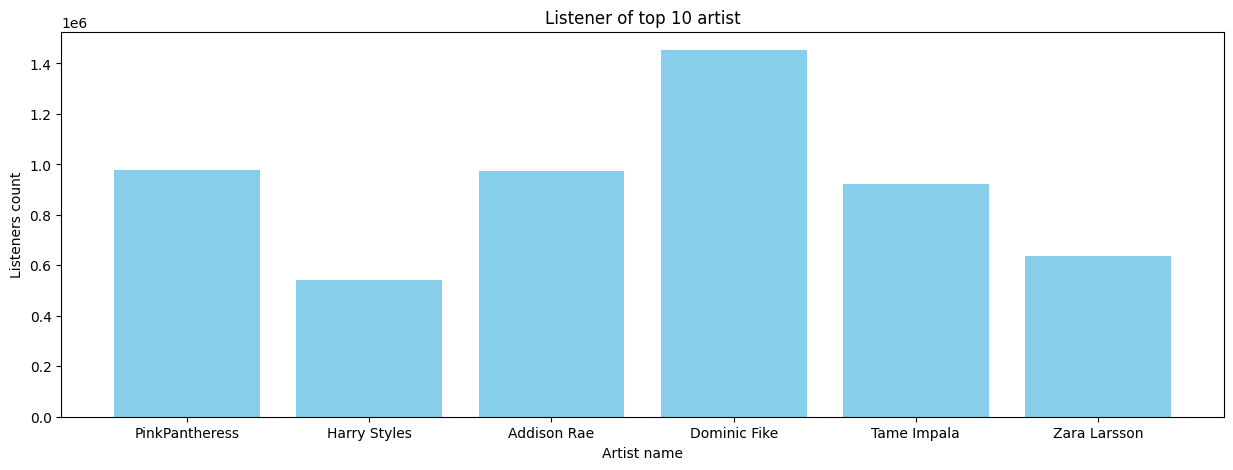

In [ ]:
df_top10 = music.head(10)
df_top10
df_top10['duration'] = pd.to_numeric(df_top10['duration'], errors='coerce')
df_top10['listeners'] = pd.to_numeric(df_top10['listeners'], errors='coerce')

df_top10['artist_name'] = df_top10['artist'].apply(lambda x: x['name'])

plt.figure(figsize = (15, 5))

plt.bar(df_top10['artist_name'], df_top10['listeners'], color = ['skyblue'])
plt.xlabel('Artist name')
plt.ylabel('Listeners count')
plt.title("Listener of top 10 artist")
plt.show()

### Géneros musicales en tendencia global

In [ ]:

def get_trending_tags(api_key):
    url = f"https://ws.audioscrobbler.com/2.0/?method=tag.getTopTags&api_key={api_key}&format=json"
    response = requests.get(url)
    return response.json()['toptags']['tag']

api_key = '63e059c3c912a3f642daf2372484d183'
get_trending_tags(api_key)

[{'name': 'rock', 'count': 4069237, 'reach': 402894},
 {'name': 'electronic', 'count': 2498601, 'reach': 262196},
 {'name': 'seen live', 'count': 2194460, 'reach': 82557},
 {'name': 'alternative', 'count': 2130888, 'reach': 267196},
 {'name': 'pop', 'count': 2082394, 'reach': 233753},
 {'name': 'indie', 'count': 2065324, 'reach': 260434},
 {'name': 'female vocalists', 'count': 1634464, 'reach': 169157},
 {'name': 'metal', 'count': 1305623, 'reach': 159014},
 {'name': 'alternative rock', 'count': 1230081, 'reach': 170245},
 {'name': 'jazz', 'count': 1196406, 'reach': 149971},
 {'name': 'classic rock', 'count': 1149319, 'reach': 137113},
 {'name': 'ambient', 'count': 1125337, 'reach': 150169},
 {'name': 'experimental', 'count': 1111936, 'reach': 145396},
 {'name': 'folk', 'count': 958605, 'reach': 151353},
 {'name': 'indie rock', 'count': 928875, 'reach': 137424},
 {'name': 'punk', 'count': 919672, 'reach': 145492},
 {'name': 'Hip-Hop', 'count': 919197, 'reach': 131432},
 {'name': 'hard 

In [ ]:
ret_generes = get_trending_tags(api_key)
top_generes = pd.DataFrame(ret_generes)[['name', 'count', 'reach']]
top_generes.head()

,name,count,reach
0,rock,4069237,402894
1,electronic,2498601,262196
2,seen live,2194460,82557
3,alternative,2130888,267196
4,pop,2082394,233753


## **2. Fraude en streams:**

Se usan los datos de Last.fm API también.

OBjetivo: Analizar el comportamiento de los usuarios para detectar anomalias. A través de la informaticón de timestamps y time_between_streams de podría averiguar si esa cuenta ussuario es un humano o un bot.
+
EDA: analisis outliers- usarios vs diferencia de tiempo

ML:clusterung

### Obtener el historial de un usuario para revisar anomalías

In [ ]:
# api_key = '63e059c3c912a3f642daf2372484d183'
# username = ['listeners'] # duda como sacarlo¿?
# def check_user_activity(api_key, username):
#     url = f"https://ws.audioscrobbler.com/2.0/?method=user.getRecentTracks&user={username}&api_key={api_key}&format=json"
#     data = requests.get(url).json()
#     # Aquí podrías calcular la diferencia de tiempo entre tracks (feature engineering) [5]
#     return data['recenttracks']['track']

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, 

#### Con API FREESOUND

In [ ]:
import requests
import pandas as pd

API_KEY = "63e059c3c912a3f642daf2372484d183"

def get_user_friends(username):
    """Obtiene la lista de amigos de un usuario para expandir la base de datos."""
    url = f"https://ws.audioscrobbler.com/2.0/?method=user.getfriends&user={username}&api_key={API_KEY}&format=json"
    response = requests.get(url).json()
    # Extraemos solo los nombres de usuario de la lista de amigos
    if 'friends' in response:
        return [friend['name'] for friend in response['friends']['user']]
    return []

def get_recent_tracks(username):
    """Obtiene el historial reciente para detectar patrones de fraude."""
    url = f"https://ws.audioscrobbler.com/2.0/?method=user.getrecenttracks&user={username}&api_key={API_KEY}&format=json"
    data = requests.get(url).json()
    if 'recenttracks' in data:
        return data['recenttracks']['track']
    return []


In [ ]:

# --- Ejemplo de flujo de trabajo ---
# 1. Empezamos con 'rj' y buscamos a sus amigos
usuarios_iniciales = get_user_friends("rj")
usuarios_iniciales[:5]

['Babs_05', 'franhale', 'eartle', 'massdosage', 'Knapster01']

In [ ]:

# 2. Recolectamos datos de escucha de esos nuevos usuarios
lista_total_escuchas = []
for user in usuarios_iniciales[:5]:  # Limitamos a 5 para el ejemplo
    tracks = get_recent_tracks(user)
    for t in tracks:
        t['user_id'] = user  # Añadimos el ID de usuario para el análisis [3]
        lista_total_escuchas.append(t)


In [ ]:

# 3. Creamos el DataFrame para tu EDA [4]
df_escuchas = pd.DataFrame(lista_total_escuchas)
df_escuchas.head()

,artist,streamable,image,mbid,album,name,url,date,user_id
0,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",7e09ca67-062d-434e-a455-09422897f35c,{'mbid': '22e8329a-ba62-4cfe-add6-6a33af9edf9c...,In Another Life,https://www.last.fm/music/Nation+of+Language/_...,"{'uts': '1773799226', '#text': '18 Mar 2026, 0...",Babs_05
1,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",9189423c-ebef-407b-928a-26d04468fe1c,{'mbid': '22e8329a-ba62-4cfe-add6-6a33af9edf9c...,Can't Face Another One,https://www.last.fm/music/Nation+of+Language/_...,"{'uts': '1773798983', '#text': '18 Mar 2026, 0...",Babs_05
2,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",,"{'mbid': '', '#text': 'Facing the Sun'}",Facing the Sun,https://www.last.fm/music/Nick+Byrne/_/Facing+...,"{'uts': '1773798717', '#text': '18 Mar 2026, 0...",Babs_05
3,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",,"{'mbid': '', '#text': 'This Is a Wake up Call'}",This Is a Wake up Call,https://www.last.fm/music/Nick+Byrne/_/This+Is...,"{'uts': '1773798472', '#text': '18 Mar 2026, 0...",Babs_05
4,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",,"{'mbid': '', '#text': 'This Is a Wake up Call'}",This Is a Wake up Call,https://www.last.fm/music/Nick+Byrne/_/This+Is...,"{'uts': '1773798220', '#text': '18 Mar 2026, 0...",Babs_05


In [ ]:
df_escuchas['artist'][0]

{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650', '#text': 'Nation of Language'}

In [ ]:
df_escuchas['artist_name'] = df_escuchas['artist'].apply(lambda x: x['#text'])
df_escuchas.drop(['mbid','album','url','image'],axis=1)

,artist,streamable,name,date,user_id,artist_name
0,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,In Another Life,"{'uts': '1773799226', '#text': '18 Mar 2026, 0...",Babs_05,Nation of Language
1,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,Can't Face Another One,"{'uts': '1773798983', '#text': '18 Mar 2026, 0...",Babs_05,Nation of Language
2,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,Facing the Sun,"{'uts': '1773798717', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
3,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,This Is a Wake up Call,"{'uts': '1773798472', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
4,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,This Is a Wake up Call,"{'uts': '1773798220', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
...,...,...,...,...,...,...
245,{'mbid': '2976cde2-cc17-49c3-b556-aed288ca72dd...,0,And Eternity,"{'uts': '1773532669', '#text': '14 Mar 2026, 2...",Knapster01,The Funkyverse
246,{'mbid': '2976cde2-cc17-49c3-b556-aed288ca72dd...,0,And Eternity,"{'uts': '1773505498', '#text': '14 Mar 2026, 1...",Knapster01,The Funkyverse
247,"{'mbid': '', '#text': 'Thing'}",0,Lost In The Haze,"{'uts': '1773503998', '#text': '14 Mar 2026, 1...",Knapster01,Thing
248,{'mbid': '9b2bc7f4-ac90-4c06-8f6e-e0b4f25b24fe...,0,Gum Bump,"{'uts': '1773503529', '#text': '14 Mar 2026, 1...",Knapster01,setting


In [ ]:
df_escuchas.drop(['mbid','album','url','image'],axis=1)

,artist,streamable,name,date,user_id,artist_name
0,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,In Another Life,"{'uts': '1773799226', '#text': '18 Mar 2026, 0...",Babs_05,Nation of Language
1,{'mbid': '88927646-0c28-4b1b-a69e-cb33c400d650...,0,Can't Face Another One,"{'uts': '1773798983', '#text': '18 Mar 2026, 0...",Babs_05,Nation of Language
2,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,Facing the Sun,"{'uts': '1773798717', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
3,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,This Is a Wake up Call,"{'uts': '1773798472', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
4,{'mbid': '9efd0502-2b2d-42ea-847c-ddbbf4b9df46...,0,This Is a Wake up Call,"{'uts': '1773798220', '#text': '18 Mar 2026, 0...",Babs_05,Nick Byrne
...,...,...,...,...,...,...
245,{'mbid': '2976cde2-cc17-49c3-b556-aed288ca72dd...,0,And Eternity,"{'uts': '1773532669', '#text': '14 Mar 2026, 2...",Knapster01,The Funkyverse
246,{'mbid': '2976cde2-cc17-49c3-b556-aed288ca72dd...,0,And Eternity,"{'uts': '1773505498', '#text': '14 Mar 2026, 1...",Knapster01,The Funkyverse
247,"{'mbid': '', '#text': 'Thing'}",0,Lost In The Haze,"{'uts': '1773503998', '#text': '14 Mar 2026, 1...",Knapster01,Thing
248,{'mbid': '9b2bc7f4-ac90-4c06-8f6e-e0b4f25b24fe...,0,Gum Bump,"{'uts': '1773503529', '#text': '14 Mar 2026, 1...",Knapster01,setting


#### Con API MSD

In [ ]:
import pandas as pd

# Conceptualmente, así cargarías el subconjunto de datos de usuarios (Taste Profile)
# Este dataset suele venir en formato triplet (user_id, song_id, play_count)
def load_msd_user_data(file_path):
    # Cargamos el archivo (ejemplo con un archivo de texto tabulado)
    df_msd = pd.read_csv(file_path, sep='\t', names=['user_id', 'song_id', 'play_count'])
    
    # Feature Engineering para Detección de Fraude [3]:
    # Calculamos el 'repeat_ratio' que propusiste en tu documentación
    user_stats = df_msd.groupby('user_id')['play_count'].agg(['sum', 'max']).reset_index()
    user_stats['repeat_ratio'] = user_stats['max'] / user_stats['sum']
    
    # Identificamos posibles anomalías (por ejemplo, alguien que escucha una sola canción el 90% del tiempo)
    posibles_bots = user_stats[user_stats['repeat_ratio'] > 0.9]
    return posibles_bots


**NOTAS**

* Pipeline:

stream logs
↓
feature engineering
↓
EDA
↓
anomaly detection
↓
fraud score

* Modelo  ML debe buscar patrones como: 1000 streams, desde 1 usuario, en 1 hora, duración promedio 5 segundos

## **3. Detector de copyright usando IA (Music Information Retrieval (MIR)):**

Freesound proporciona descriptores de audio precomputados:

. Puedes obtener datos técnicos como: 

* MFCC (Mel-frequency cepstrum coefficients): Esenciales para la identificación de timbres

* Vectores de similitud (como LAION-CLAP): Diseñados para capturar propiedades acústicas y semánticas, ideales para sistemas de huella digital (audio fingerprinting)

. Análisis espectral: Incluye centroide espectral, complejidad y energía, que sirven para crear los espectrogramas que mencionas

Objetivo: Sound Analysis: 

1. En lugar de procesar el audio tú mismo desde cero, solicita directamente los descriptores mfcc, spectral_centroid y rhythm.bpm
2. Web Audio API: Úsala en el frontend de tu plataforma para que cuando el usuario suba una canción se genere el espectrograma visual

In [ ]:
# sound_id = 
# token = 
# def get_sound_features(sound_id, token):
#     # Solicitamos MFCC para el timbre y Spectral Centroid para el brillo [9, 10]
#     url = f"https://freesound.org/apiv2/sounds/{sound_id}/analysis/"
#     headers = {'Authorization': f'Token {token}'}
#     params = {'fields': 'mfcc,spectral_centroid,rhythm.bpm'}
    
#     response = requests.get(url, headers=headers, params=params)
#     return response.json()